In [ ]:

import os

os.environ["JAX_ENABLE_X64"] = "1"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.2"

%matplotlib widget

import jax
import matplotlib.pyplot as plt
import numpy as np

from temgym_core.components import Detector
from temgym_core.gaussian import (
    run_to_end_vmapped,
    InterpolatedSample2D,
    KrivanekLens,
    Biprism,
    sample_input_wave,
)
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper
from temgym_core.transfer_matrices import calculate_z1_and_z2_from_M_and_f
from temgym_core.constants import energy2wavelength, interaction_constant_CE
from temgym_core.aberrations import KrivanekCoeffs
from temgym_core.utils import make_tilted_uniform_cube, project_phase_along_z
from scipy.ndimage import gaussian_filter

from libertem_holo.base.reconstr import reconstruct_frame, phase_unwrap
from libertem_holo.base.utils import HoloParams, remove_phase_ramp
from libertem_holo.base.align import get_slice_fft
from libertem_holo.base.filters import clipped
from libertem_ui.figure import ApertureFigure

jax.config.update("jax_enable_x64", True)


In [ ]:
def make_sample_interpolant(input_cube_xy, input_cube_side_length, input_cube_x_tilt, voltage_eV):
    k = 2 * np.pi / energy2wavelength(voltage_eV)
    simulation_side_length = input_cube_side_length * 2
    cube_fraction = input_cube_side_length / simulation_side_length
    sample_fields, sample_x_coords, sample_y_coords, sample_z_coords = make_tilted_uniform_cube(
        tilt_x=input_cube_x_tilt,
        L=simulation_side_length,
        cube_fraction=cube_fraction,
        x0=input_cube_xy[0],
        y0=input_cube_xy[1],
        B0=0.0,
        V0=15,
        amplitude_dampening=0.5,
    )
    sample_amp, sample_phase_shift = project_phase_along_z(
        fields=sample_fields,
        z_coords=sample_z_coords,
        voltage=voltage_eV,
    )

    # Blur the amplitude to remove sharp edges
    sample_amp = gaussian_filter(sample_amp, sigma=24.0)

    sample_field = sample_amp * np.exp(1j * sample_phase_shift / k)

    sample_interpolator = InterpolatedSample2D.from_array(
        sample=sample_field,
        x_coords=sample_x_coords,
        y_coords=sample_y_coords,
        z=0.0,
        method='cubic'
    ).interpolator

    return sample_interpolator, sample_x_coords, sample_y_coords, sample_field


In [3]:
def run_model(
    input_window_width_m=1e-6,
    fringe_spacing=6e-9,
    num_pixels=512,
    voltage_eV=200e3,
    input_cube_xy=(0.0, 0.0),
    input_cube_x_tilt=0.0,
    input_cube_side_length=50e-9,
    obj_focal_length=2.5e-3,
    obj_magnification=-1,
    defocus=0.0,
    beam_waist=2e-9,
    overlap_factor=2.0,
    detector_rotation=0.0,
    show_plots=False,
):
    """
    Simulate a hologram with an optional quick look at the fields.
    """
    wavelength = energy2wavelength(voltage_eV)
    pixel_size = input_window_width_m / num_pixels

    sample_interpolator, sample_x_coords, sample_y_coords, sample_field = make_sample_interpolant(
        input_cube_xy=input_cube_xy,
        input_cube_side_length=input_cube_side_length,
        input_cube_x_tilt=input_cube_x_tilt,
        voltage_eV=voltage_eV,
    )

    rays_in = sample_input_wave(
        voltage=voltage_eV,
        aperture_length=input_window_width_m * 1.0,
        waist=beam_waist,
        overlap_factor=overlap_factor,
        z0=defocus,
        sample_interpolator=sample_interpolator,
    )

    input_grid = Detector(
        z=0.0,
        pixel_size=(pixel_size, pixel_size),
        shape=(num_pixels, num_pixels),
    )

    input_field = evaluate_gaussians_gpu_kernel_wrapper(rays_in, input_grid).block_until_ready()

    if show_plots:
        fig, axs = plt.subplots(1, 2)
        axs[0].imshow(np.abs(input_field), extent=input_grid.extent, cmap='inferno')
        axs[0].set_title('Input Field Amplitude')
        axs[1].imshow(np.angle(input_field), extent=input_grid.extent, cmap='twilight')
        axs[1].set_title('Input Field Phase')
        plt.tight_layout()

    z1, z2 = calculate_z1_and_z2_from_M_and_f(
        M=obj_magnification,
        f=obj_focal_length,
    )
    z1, z2 = map(abs, (z1, z2))

    biprism_z = z1 + obj_focal_length + ((z1 + z2) - (z1 + obj_focal_length)) / 2
    a = biprism_z - (z1 + obj_focal_length)
    b = ((z1 + z2) - biprism_z)

    L = a + b
    assert L == z1 + z2 - (z1 + obj_focal_length)

    b_def = wavelength * (a + b) / (2 * fringe_spacing * a)

    aberration_coefficients = KrivanekCoeffs(
        phi12=0.0,
    )
    objective_lens = KrivanekLens(z=z1, focal_length=obj_focal_length, coeffs=aberration_coefficients)
    biprism = Biprism(z=biprism_z, strength=b_def, width=1e-15)

    detector = Detector(
        z=z1 + z2,
        pixel_size=(pixel_size, pixel_size),
        shape=(num_pixels, num_pixels),
        rotation=detector_rotation,
    )

    rays_out_with_sample = run_to_end_vmapped(rays_in, (objective_lens, biprism, detector))
    output_hologram = evaluate_gaussians_gpu_kernel_wrapper(rays_out_with_sample, detector).block_until_ready()

    # Add gaussian noise to simulate detector noise
    noise_level = 0.05 * np.max(np.abs(output_hologram))
    noise = noise_level * (np.random.normal(size=output_hologram.shape) + 1j * np.random.normal(size=output_hologram.shape))
    output_hologram += noise
    
    if show_plots:
        fig, axs = plt.subplots(1, 1)
        axs.imshow(np.abs(output_hologram), cmap='gray')
        axs.set_title('Hologram Intensity With Sample')

    return input_field, output_hologram



## Simulate holograms for multiple detector rotations
The cell below runs the microscope model for a list of sample cube rotations and stores the results so the reconstruction pipeline can iterate over them.


/nobackup/dl277493/.pyenv/versions/JaxGym/lib/python3.12/site-packages/jax/_src/numpy/lax_numpy.py:5732: FutureWarning: None encountered in jnp.array(); this is currently treated as NaN. In the future this will result in an error.
  return array(a, dtype=dtype, copy=bool(copy), order=order, device=device)


Generated 2 holograms for rotations: [0, 180]


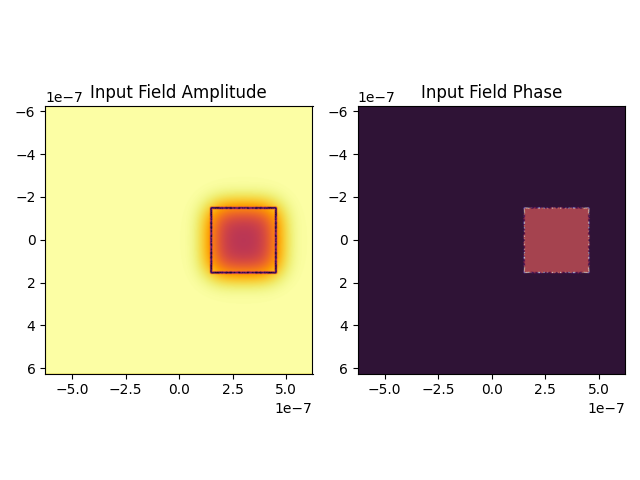

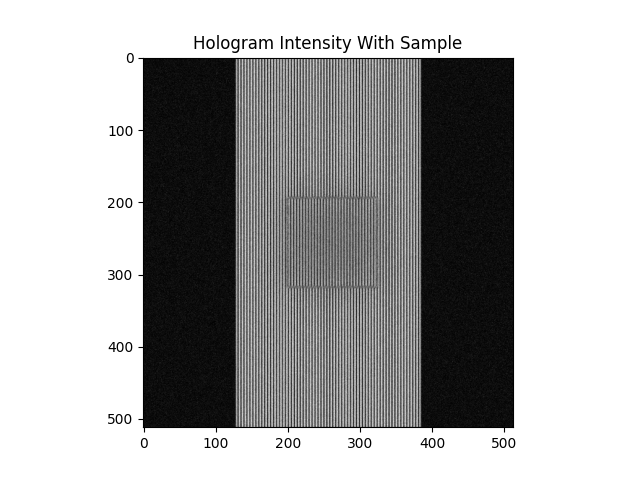

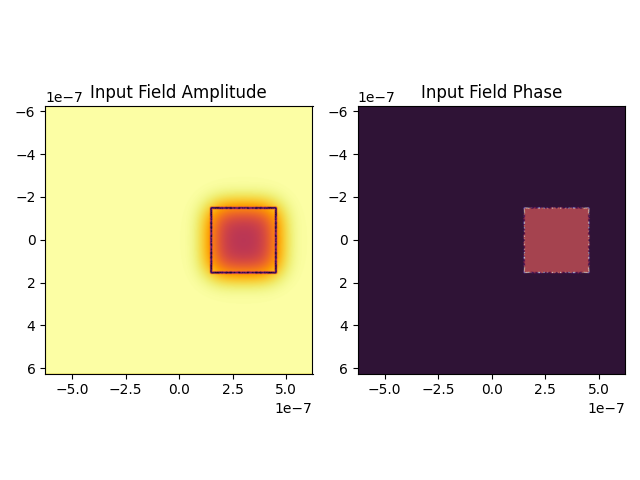

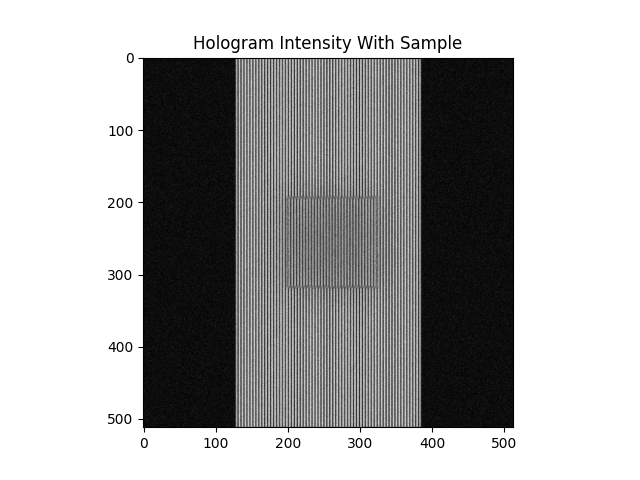

In [4]:
square_side_length = 300e-9
square_centre = (0.3e-6, 0.0e-6)
base_simulation_kwargs = dict(
    voltage_eV=200e3,
    input_window_width_m=1250e-9,
    fringe_spacing=10e-9,
    num_pixels=512,
    beam_waist=3e-9,
    input_cube_xy=square_centre,
    input_cube_side_length=square_side_length,
    input_cube_x_tilt=np.deg2rad(0),
    obj_magnification=-1,
    show_plots=True,
)

sample_rotations = [0, 180]
results = {}

for rotation in sample_rotations:
    sim_kwargs = {**base_simulation_kwargs, "input_cube_x_tilt": np.deg2rad(rotation)}
    input_field, output_hologram = run_model(**sim_kwargs)
    hologram = np.abs(output_hologram) ** 2
    results[rotation] = dict(
        input_field=input_field,
        output_hologram=output_hologram,
        hologram=hologram,
        sim_kwargs=sim_kwargs,
    )

print(f"Generated {len(results)} holograms for rotations: {list(results)}")


## Helper functions for cropping and reconstruction
These functions let us reuse the same pipeline for every hologram in `results`.


In [5]:
def crop_hologram(hologram, start=129, size=256):
    row = slice(start, start + size)
    col = slice(start, start + size)
    return hologram[row, col], (row, col)


def reconstruct_hologram(hologram, ramp_roi, out_shape=None):
    if out_shape is None:
        out_shape = hologram.shape

    holo_params = HoloParams.from_hologram(
        hologram=hologram,
        out_shape=out_shape,
        central_band_mask_radius=20
    )
    slice_fft = get_slice_fft(sig_shape=hologram.shape, out_shape=out_shape)

    wave_obj = reconstruct_frame(
        frame=hologram,
        slice_fft=slice_fft,
        aperture=holo_params.aperture,
        sb_pos=holo_params.sb_position,
    )

    phase = phase_unwrap(np.angle(wave_obj))
    phase, _, _ = remove_phase_ramp(phase, roi=ramp_roi[0])
    phase = phase - np.min(np.abs(phase))
    fft = np.abs(np.fft.fft2(hologram))

    return dict(
        wave_obj=wave_obj,
        phase=phase,
        fft=fft,
        holo_params=holo_params,
        slice_fft=slice_fft,
        sb_pos=holo_params.sb_position,
    )


def phase_cross_sections(phase, ground_truth_phase, measured_phase_roi, ground_truth_phase_roi):
    measured_phase = np.mean(phase[measured_phase_roi[0]], axis=0)
    measured_phase = measured_phase - np.mean(measured_phase)

    gt_phase = np.mean(ground_truth_phase[ground_truth_phase_roi[0]], axis=0)
    gt_phase = gt_phase - np.mean(gt_phase)

    return measured_phase, gt_phase


def process_all_holograms(
    results,
    crop_start,
    crop_size,
    ramp_roi,
    measured_phase_roi,
    ground_truth_phase_roi,
):
    """Crop, reconstruct, and extract cross-sections for every hologram."""
    processed = {}
    for rotation, data in results.items():
        cropped_hologram, _ = crop_hologram(
            data["hologram"], start=crop_start, size=crop_size
        )
        reconstruction = reconstruct_hologram(
            cropped_hologram,
            ramp_roi=ramp_roi,
            out_shape=cropped_hologram.shape,
        )

        input_phase = phase_unwrap(np.angle(data["input_field"]))
        measured_phase, ground_truth_phase = phase_cross_sections(
            reconstruction["phase"],
            input_phase,
            measured_phase_roi,
            ground_truth_phase_roi,
        )

        processed[rotation] = {
            **reconstruction,
            "cropped_hologram": cropped_hologram,
            "input_field_phase": input_phase,
            "measured_phase_cross_section": measured_phase,
            "ground_truth_phase_cross_section": ground_truth_phase,
        }

    return processed


## Pick ramp ROI once on a reference hologram
Draw a rectangle over a fringe-only area; the same ROI will be reused for every rotation.


In [6]:
crop_start = 129
crop_size = 256
reference_rotation = sample_rotations[0]

reference_hologram, crop_slices = crop_hologram(
    results[reference_rotation]["hologram"], start=crop_start, size=crop_size
)
out_shape = reference_hologram.shape

fig = ApertureFigure.new(reference_hologram)
fig.add_mask_tools(rectangles=True, polygons=False)
fig.layout


BokehModel(combine_events=True, render_bundle={'docs_json': {'b63d764b-ccd5-4a4b-88c3-7fb0fdc8f14b': {'version…

In [9]:
ramp_roi = fig.get_mask_rect_as_slices(reference_hologram.shape)
print("Ramp ROI:", ramp_roi, "Cropped shape:", reference_hologram.shape)


Ramp ROI: [(slice(12, 38, None), slice(25, 236, None))] Cropped shape: (256, 256)



## Reconstruct the reference hologram and select measurement ROIs
Use the figures to choose the sideband position, the measured phase ROI, and a ground-truth ROI on the simulated input field. Those choices will be re-used for all holograms.


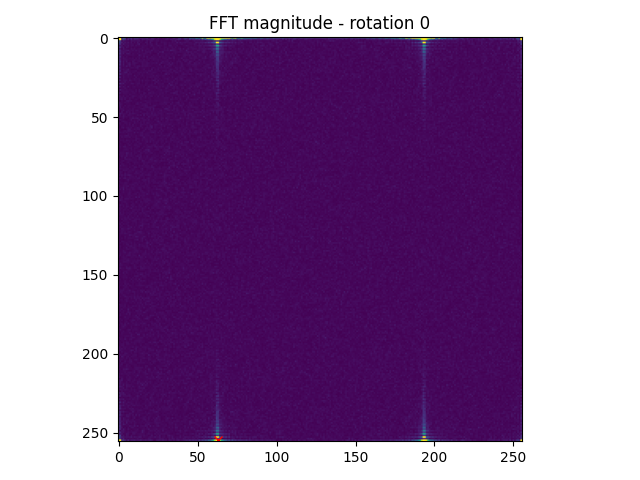

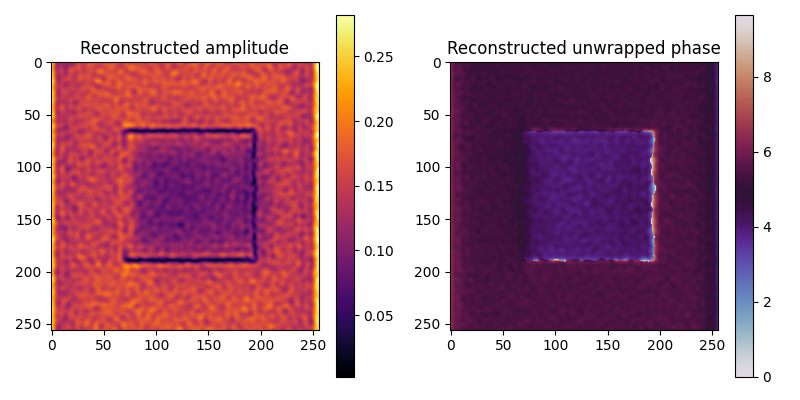

In [10]:
reference_reconstruction = reconstruct_hologram(
    reference_hologram,
    ramp_roi=ramp_roi,
    out_shape=out_shape,
)

sb_pos = reference_reconstruction["sb_pos"]

plt.figure()
plt.imshow(
    reference_reconstruction["fft"],
    vmin=np.min(clipped(reference_reconstruction["fft"])),
    vmax=np.max(clipped(reference_reconstruction["fft"])),
)
plt.plot(sb_pos[1], sb_pos[0], 'rx')
plt.title(f"FFT magnitude - rotation {reference_rotation}")
plt.tight_layout()

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
im0 = axs[0].imshow(np.abs(reference_reconstruction["wave_obj"]), cmap='inferno')
axs[0].set_title('Reconstructed amplitude')
fig.colorbar(im0, ax=axs[0])
im1 = axs[1].imshow(reference_reconstruction["phase"], cmap='twilight')
axs[1].set_title('Reconstructed unwrapped phase')
fig.colorbar(im1, ax=axs[1])
plt.tight_layout()


In [ ]:

fig = ApertureFigure.new(reference_reconstruction["phase"])
fig.add_mask_tools(rectangles=True, polygons=False)
fig.layout


BokehModel(combine_events=True, render_bundle={'docs_json': {'028ae26a-b5c6-461f-8faf-de0dd24ed6b5': {'version…

In [11]:

measured_phase_roi = fig.get_mask_rect_as_slices(reference_reconstruction["phase"].shape)
print("Measured phase ROI:", measured_phase_roi)


AttributeError: 'Figure' object has no attribute 'get_mask_rect_as_slices'

In [ ]:

input_field_phase = phase_unwrap(np.angle(results[reference_rotation]["input_field"]))
fig = ApertureFigure.new(input_field_phase)
fig.add_mask_tools(rectangles=True, polygons=False)
fig.layout


BokehModel(combine_events=True, render_bundle={'docs_json': {'081e41f7-46fe-452a-b947-94d055a4f111': {'version…

In [ ]:

ground_truth_phase_roi = fig.get_mask_rect_as_slices(input_field_phase.shape)
print("Ground truth phase ROI:", ground_truth_phase_roi)


Ground truth phase ROI: [(slice(226, 269, None), slice(227, 500, None))]



## Apply the pipeline to every hologram
Run `process_all_holograms` so every entry in `results` is cropped, reconstructed, and compared using the shared ROIs and sideband.


In [ ]:

processed_results = process_all_holograms(
    results=results,
    crop_start=crop_start,
    crop_size=crop_size,
    ramp_roi=ramp_roi,
    measured_phase_roi=measured_phase_roi,
    ground_truth_phase_roi=ground_truth_phase_roi,
)

print(
    f"Processed {len(processed_results)} holograms using shared ROIs and sideband: {sorted(processed_results)}"
)


Processed 2 holograms using shared ROIs and sideband: [0, 180]


In [ ]:
def get_phase_sign(rotation):
    """
    Returns -1 if rotation is 180 degrees, otherwise 1.
    """
    if rotation == 0:
        return -1
    return 1

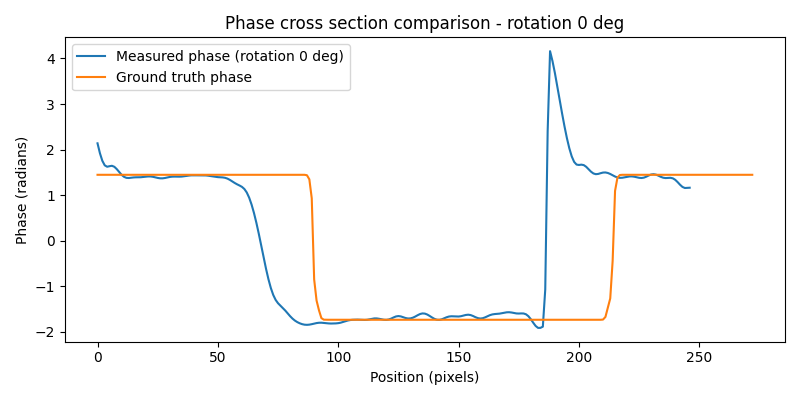

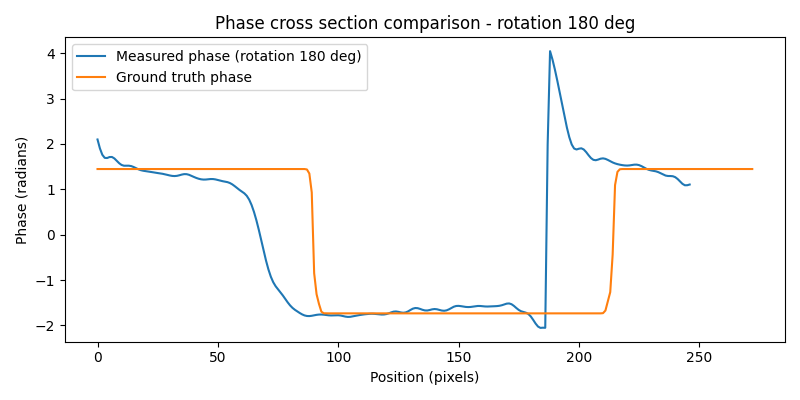

In [ ]:

for rotation in sorted(processed_results):
    data = processed_results[rotation]
    sign = get_phase_sign(rotation)
    plt.figure(figsize=(8, 4))
    plt.plot(
        data["measured_phase_cross_section"],
        label=f"Measured phase (rotation {rotation} deg)",
    )
    plt.plot(
        data["ground_truth_phase_cross_section"],
        label="Ground truth phase",
    )
    plt.xlabel('Position (pixels)')
    plt.ylabel('Phase (radians)')
    plt.legend()
    plt.title(f"Phase cross section comparison - rotation {rotation} deg")
    plt.tight_layout()


In [ ]:
measured_potentials = []

reference_cube_phase = processed_results[0]["measured_phase_cross_section"]
C_E = interaction_constant_CE(base_simulation_kwargs["voltage_eV"])
print(C_E)
thickness = base_simulation_kwargs["input_cube_side_length"]
print(thickness)
for rotation in sorted(processed_results):
    if rotation == 0:
        continue

    data = processed_results[rotation]
    
    rotated_cube_phase = data["measured_phase_cross_section"]
    
    reference_cube_phase += abs(np.min(reference_cube_phase))
    rotated_cube_phase += abs(np.min(rotated_cube_phase))

    phi_el = (reference_cube_phase + rotated_cube_phase) / 2
    phi_mag = (reference_cube_phase - rotated_cube_phase) / 2

    phi_el = np.average(phi_el)
    phi_mag = phi_mag - np.min(np.abs(phi_mag))
    
    mean_inner_potential = 3.2 / (C_E * thickness)
    measured_potentials.append(mean_inner_potential)


print("-" * 60)
print(f"Average Mean Inner Potential: {np.mean(measured_potentials):.2f} V")

7288401.085927864
3e-07
------------------------------------------------------------
Average Mean Inner Potential: 1.46 V


In [ ]:
(C_E * thickness) * 10

Array(21.86520326, dtype=float64, weak_type=True)